In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

In [3]:
df=pd.read_csv('apps.csv')
df.head()

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [4]:
print("Loading and cleaning data...")
df = pd.read_csv('user_reviews.csv')

Loading and cleaning data...


In [5]:
df = df.dropna(subset=['Translated_Review', 'Sentiment'])

In [6]:
print("Converting text to numerical data...")
X = df['Translated_Review']
y = df['Sentiment']

Converting text to numerical data...


In [7]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_vectorized = vectorizer.fit_transform(X)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_vectorized, y, test_size=0.2, random_state=42)

In [9]:
print("Training the AI Model...\n")
model = MultinomialNB()
model.fit(X_train, y_train)

Training the AI Model...



,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [10]:
y_pred = model.predict(X_test)
print("--- MODEL PERFORMANCE ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}\n")
print(classification_report(y_test, y_pred))

--- MODEL PERFORMANCE ---
Accuracy: 0.74

              precision    recall  f1-score   support

    Negative       0.88      0.45      0.59      1653
     Neutral       0.85      0.10      0.18      1049
    Positive       0.72      0.98      0.83      4784

    accuracy                           0.74      7486
   macro avg       0.82      0.51      0.54      7486
weighted avg       0.77      0.74      0.69      7486



In [11]:
def predict_sentiment(review_text):
    # Vectorize the user's text and predict
    text_vector = vectorizer.transform([review_text])
    prediction = model.predict(text_vector)[0]
    return prediction
# Try changing these sentences to see how your AI reacts!
#  _______Testing the AI with some sample reviews_______
test_reviews = [
    "This app is absolute garbage, it crashes every time I open it.",
    "I absolutely love this, the best app ever made!",
    "It is an okay app. It does what it says."
]

for review in test_reviews:
    print(f"Review: '{review}'")
    print(f"AI Prediction: {predict_sentiment(review)}\n")

Review: 'This app is absolute garbage, it crashes every time I open it.'
AI Prediction: Positive

Review: 'I absolutely love this, the best app ever made!'
AI Prediction: Positive

Review: 'It is an okay app. It does what it says.'
AI Prediction: Positive



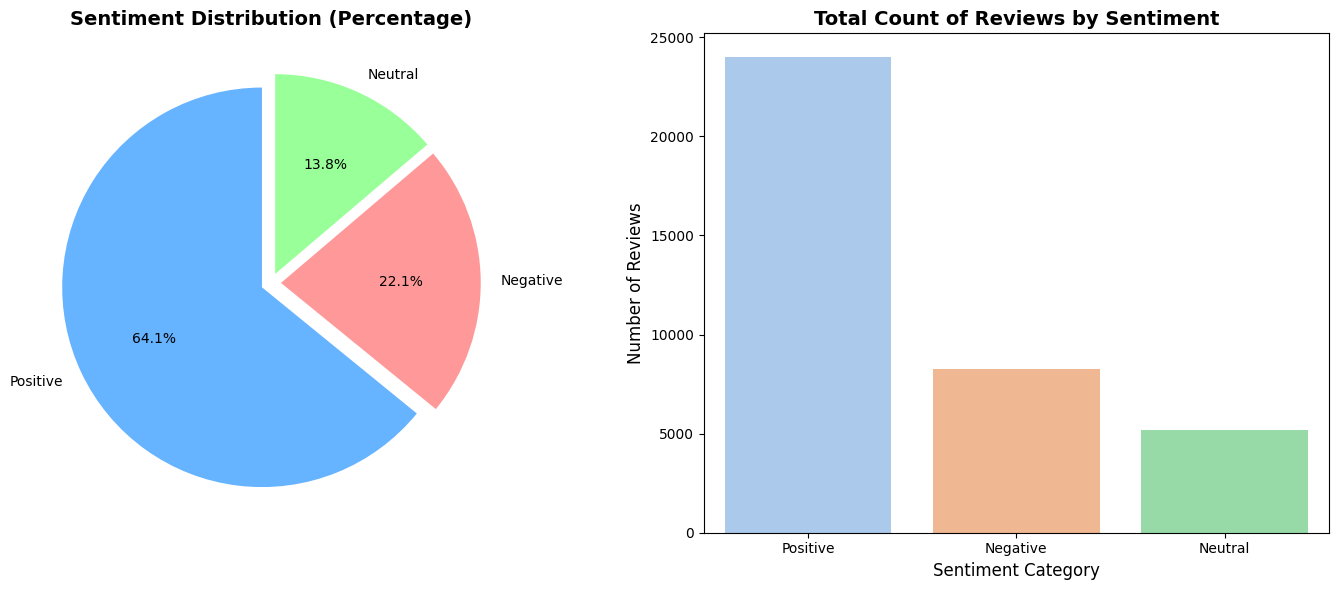

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data into a SPECIFIC variable name so it doesn't get overwritten
reviews_df = pd.read_csv('user_reviews.csv')
reviews_df = reviews_df.dropna(subset=['Translated_Review', 'Sentiment'])

# 2. Count how many Positive, Negative, and Neutral reviews exist
sentiment_counts = reviews_df['Sentiment'].value_counts()

# 3. Set up the visual canvas (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# The Pie Chart (Left Side)
axes[0].pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', 
            colors=['#66b3ff', '#ff9999', '#99ff99'], startangle=90, explode=(0.05, 0.05, 0.05))
axes[0].set_title('Sentiment Distribution (Percentage)', fontsize=14, fontweight='bold')

# The Bar Chart (Right Side)
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, ax=axes[1], hue=sentiment_counts.index, palette='pastel', legend=False)
axes[1].set_title('Total Count of Reviews by Sentiment', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Reviews', fontsize=12)
axes[1].set_xlabel('Sentiment Category', fontsize=12)

# Display the dashboard
plt.tight_layout()
plt.show()